# InceptionNeXt-Tiny Plain Classifier

Four data modes: `aptos_only`, `messidor_only`, `aptos_gan`, `messidor_gan`. Plain classifier baseline.


In [1]:
# ==============================================
# CELL 1 - Imports + Config
# ==============================================
import os, sys, math, time, random, warnings, hashlib
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ── Reproducibility ───────────────────────────
SEED        = 42
NUM_CLASSES = 5
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# ── Dataset mode: uncomment exactly one mode ─────────────────────────────
# DATA_MODE = "aptos_only"
DATA_MODE = "messidor_only"
# DATA_MODE = "aptos_gan"
# DATA_MODE = "messidor_gan"
VALID_DATA_MODES = {'aptos_only', 'messidor_only', 'aptos_gan', 'messidor_gan'}
if DATA_MODE not in VALID_DATA_MODES:
    raise ValueError(f'Invalid DATA_MODE={DATA_MODE!r}. Choose one of {sorted(VALID_DATA_MODES)}')

# ── Plain backbone classifier variant ─────────
MODEL_FAMILY = "inceptionnext_tiny"
MODEL_DISPLAY_NAME = "InceptionNeXt-Tiny"
TIMM_MODEL_CANDIDATES = ['inception_next_tiny.sail_in1k', 'inception_next_tiny', 'inceptionnext_tiny']

# ── Image / batch ─────────────────────────────
IMAGE_SIZE  = 320
BATCH_SIZE  = 16
NUM_WORKERS = 2

# ── Training ─────────────────────────────────
MAX_EPOCHS              = 120
EARLY_STOPPING_PATIENCE = 10
GRAD_CLIP_NORM          = 1.0
LR_BACKBONE             = 5e-5
LR_HEAD                 = 3e-4
WEIGHT_DECAY            = 1e-4
PLATEAU_FACTOR          = 0.5
PLATEAU_PATIENCE        = 4
MIN_LR                  = 1e-6

# ── Paths ─────────────────────────────────────
RUN_NAME = f'{MODEL_FAMILY}_{DATA_MODE}'
OUTPUT_DIR      = Path('/kaggle/working') / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / 'best_val_acc.pt'

APTOS_ROOT_CANDIDATES = [
    Path('/kaggle/input/competitions/aptos2019-blindness-detection'),
    Path('/kaggle/input/aptos2019-blindness-detection'),
    Path('data/aptos2019-blindness-detection 2'),
]
APTOS_GAN_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/mainguynthanht/gan-aptos-data/GAN_Data_APTOS'),
    Path('/kaggle/input/datasets/mainguynthanht/gan-aptos-data/GAN_Data_APTOS/GAN_Data_APTOS'),
    Path('/kaggle/input/datasets/annindie/gan-aptos-data/GAN_Data_APTOS'),
]
MESSIDOR_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/mainguynthanht/messidor/Messidor'),
    Path('/kaggle/input/datasets/mainguynthanht/messidor/Messidor/Messidor'),
    Path('/kaggle/input/messidor/Messidor'),
    Path('/kaggle/input/datasets/annindie/messidor/Messidor'),
]
MESSIDOR_GAN_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/mainguynthanht/gan-messidor/GAN_Data_MESSIDOR'),
    Path('/kaggle/input/datasets/mainguynthanht/gan-messidor/GAN_Data_MESSIDOR/GAN_Data_MESSIDOR'),
    Path('/kaggle/input/datasets/annindie/gan-messidor/GAN_Data_MESSIDOR'),
]

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Device:', device)
print('DATA_MODE:', DATA_MODE)
print('Model:', MODEL_DISPLAY_NAME)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda
DATA_MODE: messidor_only
Model: InceptionNeXt-Tiny


In [2]:
# ==============================================
# CELL 2 - Utilities
# ==============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)

try:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
except Exception:
    _autocast = _GradScaler = None

class _NullScaler:
    def scale(self, loss):   return loss
    def unscale_(self, opt): pass
    def step(self, opt):     opt.step()
    def update(self):        pass

def amp_autocast():
    if USE_AMP and _autocast is not None:
        return _autocast()
    import contextlib
    return contextlib.nullcontext()

def make_scaler():
    return _GradScaler() if USE_AMP and _GradScaler is not None else _NullScaler()

def safe_torch_load(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print('Utilities ready.')


Utilities ready.


In [3]:
# ==============================================
# CELL 3 - Load APTOS/Messidor + optional GAN, Clean Real Data, Split 60/20/20
# ==============================================
IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def first_existing(candidates, check_fn, name):
    for root in candidates:
        if check_fn(root):
            return root
    raise FileNotFoundError(f'{name} not found in: ' + ', '.join(map(str, candidates)))


def find_aptos_root():
    return first_existing(
        APTOS_ROOT_CANDIDATES,
        lambda root: (root / 'train.csv').exists() and (root / 'train_images').is_dir(),
        'APTOS')


def find_messidor_root():
    return first_existing(
        MESSIDOR_ROOT_CANDIDATES,
        lambda root: (root / 'messidor_data.csv').exists() and (root / 'messidor-2' / 'messidor-2' / 'preprocess').is_dir(),
        'MESSIDOR')


def find_gan_root(candidates, name):
    def valid(root):
        if not root.exists() or not root.is_dir():
            return False
        return any((root / str(cls)).is_dir() for cls in range(NUM_CLASSES))
    return first_existing(candidates, valid, name)


def file_sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


def load_aptos_raw():
    root = find_aptos_root()
    df = pd.read_csv(root / 'train.csv')
    df['image_path'] = df['id_code'].apply(lambda x: str(root / 'train_images' / f'{x}.png'))
    df['label'] = df['diagnosis'].astype(int)
    df['source'] = 'aptos'
    missing = (~df['image_path'].apply(lambda p: Path(p).exists())).sum()
    if missing:
        raise FileNotFoundError(f'Missing {missing} APTOS images')
    df['image_hash'] = df['image_path'].apply(file_sha256)
    print(f'APTOS raw rows: {len(df)}')
    print(df['label'].value_counts().sort_index())
    return df[['image_path', 'label', 'source', 'id_code', 'image_hash']]


def load_messidor_raw():
    root = find_messidor_root()
    img_dir = root / 'messidor-2' / 'messidor-2' / 'preprocess'
    df = pd.read_csv(root / 'messidor_data.csv')
    if 'adjudicated_gradable' in df.columns:
        before = len(df)
        df = df[df['adjudicated_gradable'].fillna(0).astype(int) == 1].reset_index(drop=True)
        print(f'Messidor gradable filter: {before} -> {len(df)}')
    df['id_code'] = df['id_code'].astype(str)
    df['image_path'] = df['id_code'].apply(lambda x: str(img_dir / x))
    df['label'] = df['diagnosis'].astype(int)
    df['source'] = 'messidor'
    missing = (~df['image_path'].apply(lambda p: Path(p).exists())).sum()
    if missing:
        examples = df.loc[~df['image_path'].apply(lambda p: Path(p).exists()), 'image_path'].head(5).tolist()
        raise FileNotFoundError(f'Missing {missing} Messidor images. Examples: {examples}')
    df['image_hash'] = df['image_path'].apply(file_sha256)
    print(f'Messidor raw rows: {len(df)}')
    print(df['label'].value_counts().sort_index())
    return df[['image_path', 'label', 'source', 'id_code', 'image_hash']]


def clean_real_by_hash(df, dataset_name):
    label_nunique = df.groupby('image_hash')['label'].nunique()
    conflict_hashes = set(label_nunique[label_nunique > 1].index)
    conflict_files = int(df['image_hash'].isin(conflict_hashes).sum())
    no_conflict = df[~df['image_hash'].isin(conflict_hashes)].copy()
    before_collapse = len(no_conflict)
    clean = (no_conflict.sort_values(['image_hash', 'id_code'])
             .drop_duplicates('image_hash', keep='first')
             .reset_index(drop=True))
    collapsed_files = before_collapse - len(clean)
    print(f'\n{dataset_name} SHA-cleaning:')
    print(f'  unique raw hashes           : {df["image_hash"].nunique()}')
    print(f'  conflict hash groups dropped: {len(conflict_hashes)}')
    print(f'  conflict files dropped      : {conflict_files}')
    print(f'  same-label duplicates merged: {collapsed_files}')
    print(f'  clean rows                  : {len(clean)}')
    print(clean['label'].value_counts().sort_index())
    return clean, conflict_hashes


def load_gan(candidates, source_name):
    root = find_gan_root(candidates, source_name)
    rows = []
    for cls in range(NUM_CLASSES):
        d = root / str(cls)
        if not d.is_dir():
            continue
        for p in sorted(d.rglob('*')):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({'image_path': str(p), 'label': cls,
                             'source': source_name.lower(), 'id_code': p.stem,
                             'image_hash': f'{source_name.lower()}::{cls}::{p.stem}'})
    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=['image_path', 'label', 'source', 'id_code', 'image_hash'])
    print(f'\n{source_name} root: {root}')
    print(f'{source_name} rows: {len(df)}')
    if len(df):
        print(df['label'].value_counts().sort_index())
    return df


if DATA_MODE.startswith('aptos'):
    real_raw = load_aptos_raw()
    real_df, conflict_hashes = clean_real_by_hash(real_raw, 'APTOS')
    dataset_name = 'APTOS'
elif DATA_MODE.startswith('messidor'):
    real_raw = load_messidor_raw()
    real_df, conflict_hashes = clean_real_by_hash(real_raw, 'Messidor')
    dataset_name = 'Messidor'
else:
    raise ValueError(f'Unsupported DATA_MODE={DATA_MODE}')

use_gan = DATA_MODE in {'aptos_gan', 'messidor_gan'}
if use_gan and DATA_MODE == 'aptos_gan':
    gan_df = load_gan(APTOS_GAN_ROOT_CANDIDATES, 'GAN_APTOS')
elif use_gan and DATA_MODE == 'messidor_gan':
    gan_df = load_gan(MESSIDOR_GAN_ROOT_CANDIDATES, 'GAN_MESSIDOR')
else:
    gan_df = pd.DataFrame(columns=['image_path', 'label', 'source', 'id_code', 'image_hash'])
    print('\nGAN disabled for DATA_MODE:', DATA_MODE)

train_real, temp = train_test_split(
    real_df, test_size=0.40, random_state=SEED, stratify=real_df['label'])
val_real, test_real = train_test_split(
    temp, test_size=0.50, random_state=SEED, stratify=temp['label'])
train_real = train_real.reset_index(drop=True)
val_real = val_real.reset_index(drop=True)
test_real = test_real.reset_index(drop=True)

train_hashes = set(train_real['image_hash'])
val_hashes = set(val_real['image_hash'])
test_hashes = set(test_real['image_hash'])
assert train_hashes.isdisjoint(val_hashes)
assert train_hashes.isdisjoint(test_hashes)
assert val_hashes.isdisjoint(test_hashes)
assert train_real['image_hash'].is_unique
assert val_real['image_hash'].is_unique
assert test_real['image_hash'].is_unique

print('\nClean split:')
for n, d in [('train_real', train_real), ('val', val_real), ('test', test_real)]:
    print(f'  {n}: {len(d)}', d['label'].value_counts().sort_index().to_dict())
print('  hash crossing: none')


Messidor gradable filter: 1744 -> 1744
Messidor raw rows: 1744
label
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64

Messidor SHA-cleaning:
  unique raw hashes           : 1740
  conflict hash groups dropped: 0
  conflict files dropped      : 0
  same-label duplicates merged: 4
  clean rows                  : 1740
label
0    1017
1     268
2     345
3      75
4      35
Name: count, dtype: int64

GAN disabled for DATA_MODE: messidor_only

Clean split:
  train_real: 1044 {0: 610, 1: 161, 2: 207, 3: 45, 4: 21}
  val: 348 {0: 203, 1: 54, 2: 69, 3: 15, 4: 7}
  test: 348 {0: 204, 1: 53, 2: 69, 3: 15, 4: 7}
  hash crossing: none


In [4]:
# ==============================================
# CELL 4 - Build Train/Val/Test Manifest
# train = clean real train (+ GAN when DATA_MODE uses GAN)
# val/test = clean real only.
# ==============================================

def build_train_manifest(train_real, gan_df):
    parts = [train_real.copy()]
    if len(gan_df):
        parts.append(gan_df.copy())
    train_df = pd.concat(parts, ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    real_counts = train_real['label'].value_counts().sort_index().to_dict()
    gan_counts = gan_df['label'].value_counts().sort_index().to_dict() if len(gan_df) else {}
    plan = []
    for cls in range(NUM_CLASSES):
        real_n = int(real_counts.get(cls, 0))
        gan_n = int(gan_counts.get(cls, 0))
        plan.append((cls, real_n, gan_n, real_n + gan_n))
    plan_df = pd.DataFrame(plan, columns=['class', 'real', 'gan_used', 'total'])
    return train_df, plan_df


train_df, plan_df = build_train_manifest(train_real, gan_df)
val_df = val_real.copy().reset_index(drop=True)
test_df = test_real.copy().reset_index(drop=True)

protocol = f'{dataset_name} clean real train'
if len(gan_df):
    protocol += ' + GAN train images'
protocol += '; val/test = clean real only'
print(f'DATA_MODE protocol: {protocol}')
print(plan_df.to_string(index=False))
print('\nFinal train dist:', train_df['label'].value_counts().sort_index().to_dict())
print('Source counts:', train_df['source'].value_counts().to_dict())
print('Val dist:', val_df['label'].value_counts().sort_index().to_dict())
print('Test dist:', test_df['label'].value_counts().sort_index().to_dict())

train_df.to_csv(OUTPUT_DIR / f'train_{DATA_MODE}.csv', index=False)
val_df.to_csv(OUTPUT_DIR / f'val_{DATA_MODE}.csv', index=False)
test_df.to_csv(OUTPUT_DIR / f'test_{DATA_MODE}.csv', index=False)


DATA_MODE protocol: Messidor clean real train; val/test = clean real only
 class  real  gan_used  total
     0   610         0    610
     1   161         0    161
     2   207         0    207
     3    45         0     45
     4    21         0     21

Final train dist: {0: 610, 1: 161, 2: 207, 3: 45, 4: 21}
Source counts: {'messidor': 1044}
Val dist: {0: 203, 1: 54, 2: 69, 3: 15, 4: 7}
Test dist: {0: 204, 1: 53, 2: 69, 3: 15, 4: 7}


In [5]:
# ==============================================
# CELL 5 - Dataset + Letterbox Pad + Conservative Augmentation
# No CLAHE, Ben Graham, MixUp, CutMix. No crop.
# ==============================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class LetterboxPad:
    """Resize while preserving aspect ratio, then pad to a square canvas."""
    def __init__(self, size, fill=(0, 0, 0)):
        self.size = int(size)
        self.fill = fill

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        nw = max(1, int(round(w * scale)))
        nh = max(1, int(round(h * scale)))
        img = img.resize((nw, nh), Image.Resampling.BILINEAR)
        canvas = Image.new('RGB', (self.size, self.size), self.fill)
        canvas.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))
        return canvas


# Conservative source-aware augmentation: keep tiny DR lesions sharp and avoid crop.
real_train_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.20),
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.06, hue=0.015),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# GAN images are already 256x256 synthetic retina images; use lighter color/geometry jitter.
gan_train_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=7, fill=0),
    transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.04, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class DRDataset(Dataset):
    def __init__(self, df, mode='train'):
        self.df = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def _select_transform(self, row):
        if self.mode != 'train':
            return valid_tfms
        if str(row.get('source', '')).lower().startswith('gan') or row.get('source') == 'acfd_gan':
            return gan_train_tfms
        return real_train_tfms

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = self._select_transform(row)(img)
        label = int(row['label'])
        return img, torch.tensor(label, dtype=torch.long)


train_ds = DRDataset(train_df, mode='train')
val_ds   = DRDataset(val_df,   mode='valid')
test_ds  = DRDataset(test_df,  mode='valid')

def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    worker_init_fn=seed_worker, generator=loader_generator)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=loader_generator)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=loader_generator)

print('DataLoaders ready:')
print(f'  train: {len(train_loader)} batches')
print(f'  val  : {len(val_loader)} batches')
print(f'  test : {len(test_loader)} batches')
print('Transform: LetterboxPad + conservative source-aware augmentation')


DataLoaders ready:
  train: 66 batches
  val  : 22 batches
  test : 22 batches
Transform: LetterboxPad + conservative source-aware augmentation


In [6]:
# ==============================================
# CELL 6 - Utility
# ==============================================
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print('Plain classifier utilities ready.')


Plain classifier utilities ready.


In [7]:
# ==============================================
# CELL 7 - Plain Model: InceptionNeXt-Tiny
# ==============================================

class PlainDRClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model_family = MODEL_FAMILY
        self.impl = None
        if MODEL_FAMILY == 'densenet201':
            weights = tv_models.DenseNet201_Weights.IMAGENET1K_V1
            model = tv_models.densenet201(weights=weights)
            in_features = model.classifier.in_features
            model.classifier = nn.Linear(in_features, num_classes)
            self.model = model
            self.impl = 'torchvision.densenet201'
        else:
            try:
                import timm
            except Exception as e:
                raise ImportError(
                    'This notebook requires timm for this model. On Kaggle, enable internet and run '
                    '`pip install timm`, or attach a Kaggle dataset containing timm. '
                    f'Original import error: {e}') from e
            errors = []
            model = None
            chosen = None
            for name in TIMM_MODEL_CANDIDATES:
                try:
                    model = timm.create_model(name, pretrained=True, num_classes=num_classes)
                    chosen = name
                    break
                except Exception as e:
                    errors.append(f'{name}: {type(e).__name__}: {e}')
            if model is None:
                available_hint = []
                try:
                    prefix = TIMM_MODEL_CANDIDATES[0].split('_')[0]
                    available_hint = timm.list_models(f'{prefix}*')[:20]
                except Exception:
                    pass
                raise RuntimeError(
                    f'Could not create {MODEL_DISPLAY_NAME}. Tried: {TIMM_MODEL_CANDIDATES}.\n'
                    'Errors:\n  ' + '\n  '.join(errors) +
                    f'\nAvailable hint: {available_hint}')
            self.model = model
            self.impl = chosen

    def forward(self, x):
        return self.model(x)

    def backbone_parameters(self):
        if MODEL_FAMILY == 'densenet201':
            return self.model.features.parameters()
        head_params = set(map(id, self.head_parameters()))
        return [p for p in self.model.parameters() if id(p) not in head_params]

    def head_parameters(self):
        if MODEL_FAMILY == 'densenet201':
            return self.model.classifier.parameters()
        if hasattr(self.model, 'get_classifier'):
            classifier = self.model.get_classifier()
            if isinstance(classifier, nn.Module):
                return classifier.parameters()
        if hasattr(self.model, 'classifier') and isinstance(self.model.classifier, nn.Module):
            return self.model.classifier.parameters()
        if hasattr(self.model, 'head') and isinstance(self.model.head, nn.Module):
            return self.model.head.parameters()
        return []


model = PlainDRClassifier(num_classes=NUM_CLASSES).to(device)
total, trainable = count_parameters(model)
print(f'{MODEL_DISPLAY_NAME} plain classifier')
print(f'  implementation : {model.impl}')
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    logits = model(dummy)
print(f'Shape check - logits: {logits.shape}')


model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

InceptionNeXt-Tiny plain classifier
  implementation : inception_next_tiny.sail_in1k
Total params     : 25,762,205
Trainable params : 25,762,205
Shape check - logits: torch.Size([2, 5])


In [8]:
# ==============================================
# CELL 8 - Loss Function
# ==============================================
criterion = nn.CrossEntropyLoss()
print('Loss: CrossEntropyLoss')


Loss: CrossEntropyLoss


In [9]:
# ==============================================
# CELL 9 - Optimizer + Scheduler
# ==============================================
head_params = list(model.head_parameters())
head_param_ids = set(map(id, head_params))
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params, 'lr': LR_HEAD, 'weight_decay': WEIGHT_DECAY},
])
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE, min_lr=MIN_LR)
scaler = make_scaler()
print(f'Optimizer: AdamW  backbone_lr={LR_BACKBONE}  head_lr={LR_HEAD}')
print(f'Scheduler: ReduceLROnPlateau on val_loss  factor={PLATEAU_FACTOR} patience={PLATEAU_PATIENCE} min_lr={MIN_LR}')


Optimizer: AdamW  backbone_lr=5e-05  head_lr=0.0003
Scheduler: ReduceLROnPlateau on val_loss  factor=0.5 patience=4 min_lr=1e-06


In [10]:
# ==============================================
# CELL 10 - Train + Validate Plain Classifier
# Scheduler / early stopping: val_loss
# Selected checkpoint: val_acc -> val_qwk -> val_loss
# ==============================================

def train_one_epoch(model, loader):
    model.train()
    total_loss, labels_all, preds_all = 0.0, [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            raise RuntimeError(f'Non-finite train loss: {loss.item()}')
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds_all.extend(logits.detach().argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, labels_all, preds_all = 0.0, [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with amp_autocast():
            logits = model(imgs)
            loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            raise RuntimeError(f'Non-finite eval loss: {loss.item()}')
        total_loss += loss.item() * imgs.size(0)
        preds_all.extend(logits.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    val_loss = total_loss / len(loader.dataset)
    val_acc = accuracy_score(labels_all, preds_all)
    val_qwk = cohen_kappa_score(labels_all, preds_all, weights='quadratic')
    return val_loss, val_acc, val_qwk


def primary_is_better(val_acc, val_qwk, val_loss, best, eps=1e-8):
    if val_acc > best['val_acc'] + eps:
        return True
    if abs(val_acc - best['val_acc']) <= eps:
        if val_qwk > best['val_qwk'] + eps:
            return True
        if abs(val_qwk - best['val_qwk']) <= eps:
            return val_loss < best['val_loss'] - eps
    return False


history = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_qwk': [],
    'bb_lr': [], 'head_lr': [], 'epoch_sec': []
}
best = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
best_loss = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
no_improve_loss = 0

hdr = (f'{"Ep":>4} | {"BB LR":>9} {"Hd LR":>9} | '
       f'{"Tr Loss":>8} {"Tr Acc":>7} | {"Va Loss":>8} {"Va Acc":>7} {"Va QWK":>7} | '
       f'{"Time":>7} | Saved')
print(hdr)
print('-' * len(hdr))

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    ep0 = time.perf_counter()
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_qwk = evaluate(model, val_loader)
    bb_lr = optimizer.param_groups[0]['lr']
    head_lr = optimizer.param_groups[1]['lr']
    scheduler.step(va_loss)
    ep_sec = time.perf_counter() - ep0
    for k, v in zip(
        ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_qwk', 'bb_lr', 'head_lr', 'epoch_sec'],
        [tr_loss, tr_acc, va_loss, va_acc, va_qwk, bb_lr, head_lr, ep_sec]
    ):
        history[k].append(v)

    saved = []
    if va_loss < best_loss['val_loss'] - 1e-6:
        best_loss = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        no_improve_loss = 0
    else:
        no_improve_loss += 1

    if primary_is_better(va_acc, va_qwk, va_loss, best):
        best = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_loss': float(va_loss),
            'val_acc': float(va_acc),
            'val_qwk': float(va_qwk),
            'selection_rule': 'val_acc -> val_qwk -> val_loss',
            'scheduler_monitor': 'val_loss',
            'early_stopping_monitor': 'val_loss',
            'model_family': MODEL_FAMILY,
            'model_display_name': MODEL_DISPLAY_NAME,
            'data_mode': DATA_MODE,
        }, BEST_MODEL_PATH)
        saved.append('primary')

    mark = ','.join(saved) if saved else '-'
    print(f'{epoch:4d} | {bb_lr:9.2e} {head_lr:9.2e} | '
          f'{tr_loss:8.4f} {tr_acc:7.4f} | {va_loss:8.4f} {va_acc:7.4f} {va_qwk:7.4f} | '
          f'{ep_sec:6.1f}s | {mark}')

    if no_improve_loss >= EARLY_STOPPING_PATIENCE:
        print(f'Early stop epoch {epoch}. Best val_loss epoch={best_loss["epoch"]}, '
              f'val_loss={best_loss["val_loss"]:.5f}')
        break

print(f'Total training: {(time.perf_counter() - t0) / 60:.1f} min')
print(f'Best checkpoint: {BEST_MODEL_PATH}')
print(f'Selected primary epoch={best["epoch"]} val_acc={best["val_acc"]*100:.2f}% '
      f'val_qwk={best["val_qwk"]:.4f} val_loss={best["val_loss"]:.5f}')
print('Selection rule: val_acc -> val_qwk -> val_loss')
print('Scheduler monitor: val_loss | Early stopping monitor: val_loss')
best_epoch = best['epoch']


  Ep |     BB LR     Hd LR |  Tr Loss  Tr Acc |  Va Loss  Va Acc  Va QWK |    Time | Saved
------------------------------------------------------------------------------------------
   1 |  5.00e-05  3.00e-04 |   1.1652  0.5575 |   1.0073  0.5948  0.0868 |   21.5s | primary
   2 |  5.00e-05  3.00e-04 |   0.9449  0.6331 |   0.9135  0.6322  0.3987 |   15.8s | primary
   3 |  5.00e-05  3.00e-04 |   0.8119  0.6638 |   0.7628  0.6983  0.6686 |   16.2s | primary
   4 |  5.00e-05  3.00e-04 |   0.7258  0.7011 |   0.6848  0.7443  0.7778 |   16.1s | primary
   5 |  5.00e-05  3.00e-04 |   0.6183  0.7567 |   0.7058  0.7414  0.7463 |   15.7s | -
   6 |  5.00e-05  3.00e-04 |   0.5667  0.7730 |   0.6489  0.7529  0.8279 |   15.6s | primary
   7 |  5.00e-05  3.00e-04 |   0.4698  0.8247 |   0.6534  0.7471  0.7841 |   16.2s | -
   8 |  5.00e-05  3.00e-04 |   0.4470  0.8209 |   0.6784  0.7816  0.8368 |   15.9s | primary
   9 |  5.00e-05  3.00e-04 |   0.3696  0.8640 |   0.6432  0.7931  0.8504 |   15.7s | p

Loaded validation-selected checkpoint: epoch=9 val_acc=79.31% val_qwk=0.8504 val_loss=0.64322
Selection rule: val_acc -> val_qwk -> val_loss

Test Accuracy : 73.85%
Kappa (QWK)   : 0.7102
AUC macro OVR : 0.8801
AUC per class:
  Grade 0 (No DR): 0.8521
  Grade 1 (Mild): 0.7025
  Grade 2 (Moderate): 0.9205
  Grade 3 (Severe): 0.9908
  Grade 4 (Proliferative DR): 0.9346

Classification report:
                  precision    recall  f1-score   support

           No DR     0.7631    0.9314    0.8389       204
            Mild     0.3939    0.2453    0.3023        53
        Moderate     0.8889    0.5797    0.7018        69
          Severe     0.7059    0.8000    0.7500        15
Proliferative DR     0.5000    0.2857    0.3636         7

        accuracy                         0.7385       348
       macro avg     0.6504    0.5684    0.5913       348
    weighted avg     0.7240    0.7385    0.7166       348



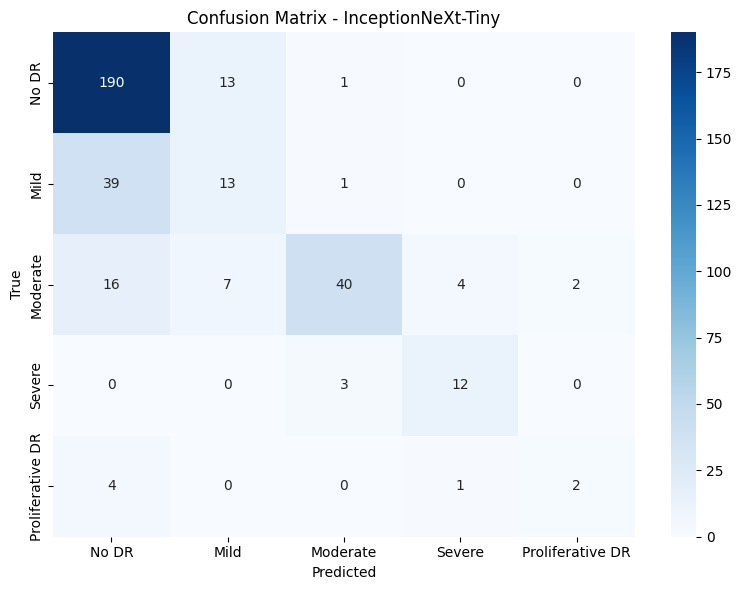

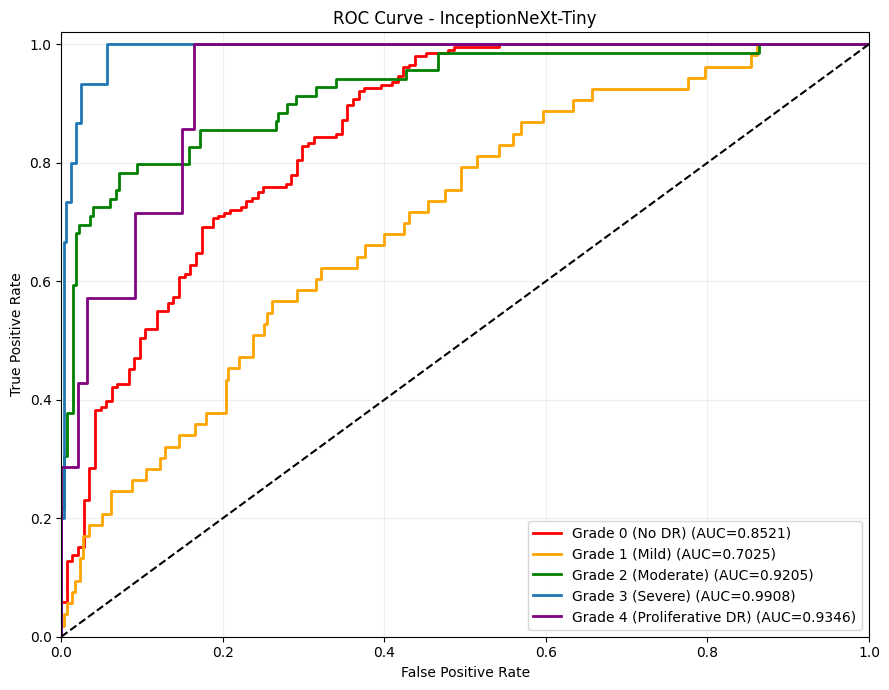

In [11]:
# ==============================================
# CELL 11 - Test Evaluation: Accuracy + Confusion Matrix + ROC/AUC + Report
# ==============================================
ckpt = safe_torch_load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded validation-selected checkpoint: epoch={ckpt["epoch"]} '
      f'val_acc={ckpt["val_acc"]*100:.2f}% val_qwk={ckpt.get("val_qwk", float("nan")):.4f} '
      f'val_loss={ckpt["val_loss"]:.5f}')
print('Selection rule: val_acc -> val_qwk -> val_loss')

@torch.no_grad()
def predict_plain(model, loader):
    labels_all, preds_all, probs_all = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        with amp_autocast():
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)
        probs_all.extend(probs.cpu().numpy())
        preds_all.extend(probs.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    return np.array(labels_all), np.array(preds_all), np.array(probs_all)


def compute_auc(y_true, y_prob):
    try:
        return roc_auc_score(
            label_binarize(y_true, classes=list(range(NUM_CLASSES))),
            y_prob, multi_class='ovr', average='macro')
    except ValueError:
        return float('nan')


def per_class_auc(y_true, y_prob):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    aucs = {}
    for cls_idx in range(NUM_CLASSES):
        if len(np.unique(y_bin[:, cls_idx])) < 2:
            aucs[cls_idx] = float('nan')
        else:
            aucs[cls_idx] = roc_auc_score(y_bin[:, cls_idx], y_prob[:, cls_idx])
    return aucs


def plot_multiclass_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    colors = ['red', 'orange', 'green', 'tab:blue', 'purple']
    plt.figure(figsize=(9, 7))
    for cls_idx, color in zip(range(NUM_CLASSES), colors):
        if len(np.unique(y_bin[:, cls_idx])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], y_prob[:, cls_idx])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'Grade {cls_idx} ({CLASS_NAMES[cls_idx]}) (AUC={cls_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


y_true, y_pred, y_prob = predict_plain(model, test_loader)
test_acc = accuracy_score(y_true, y_pred)
test_kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
test_auc = compute_auc(y_true, y_prob)
test_class_auc = per_class_auc(y_true, y_prob)

print()
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Kappa (QWK)   : {test_kappa:.4f}')
print(f'AUC macro OVR : {test_auc:.4f}')
print('AUC per class:')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    print(f'  Grade {cls_idx} ({cls_name}): {test_class_auc[cls_idx]:.4f}')
print()
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - {MODEL_DISPLAY_NAME}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

plot_multiclass_roc(y_true, y_prob, f'ROC Curve - {MODEL_DISPLAY_NAME}')


In [12]:
# ==============================================
# CELL 12 - Save Test Predictions
# ==============================================
pred_df = test_df.copy().reset_index(drop=True)
pred_df['true'] = y_true
pred_df['pred'] = y_pred
pred_df['correct'] = pred_df['true'] == pred_df['pred']
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pred_df[f'prob_{cls_idx}'] = y_prob[:, cls_idx]
pred_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
errors_df = pred_df[~pred_df['correct']].copy()
errors_df.to_csv(OUTPUT_DIR / 'test_errors.csv', index=False)
print(f'Test predictions saved: {OUTPUT_DIR / "test_predictions.csv"}')
print(f'Test errors saved     : {OUTPUT_DIR / "test_errors.csv"}')
print(f'Errors: {len(errors_df)} / {len(pred_df)}')


Test predictions saved: /kaggle/working/inceptionnext_tiny_messidor_only/test_predictions.csv
Test errors saved     : /kaggle/working/inceptionnext_tiny_messidor_only/test_errors.csv
Errors: 91 / 348


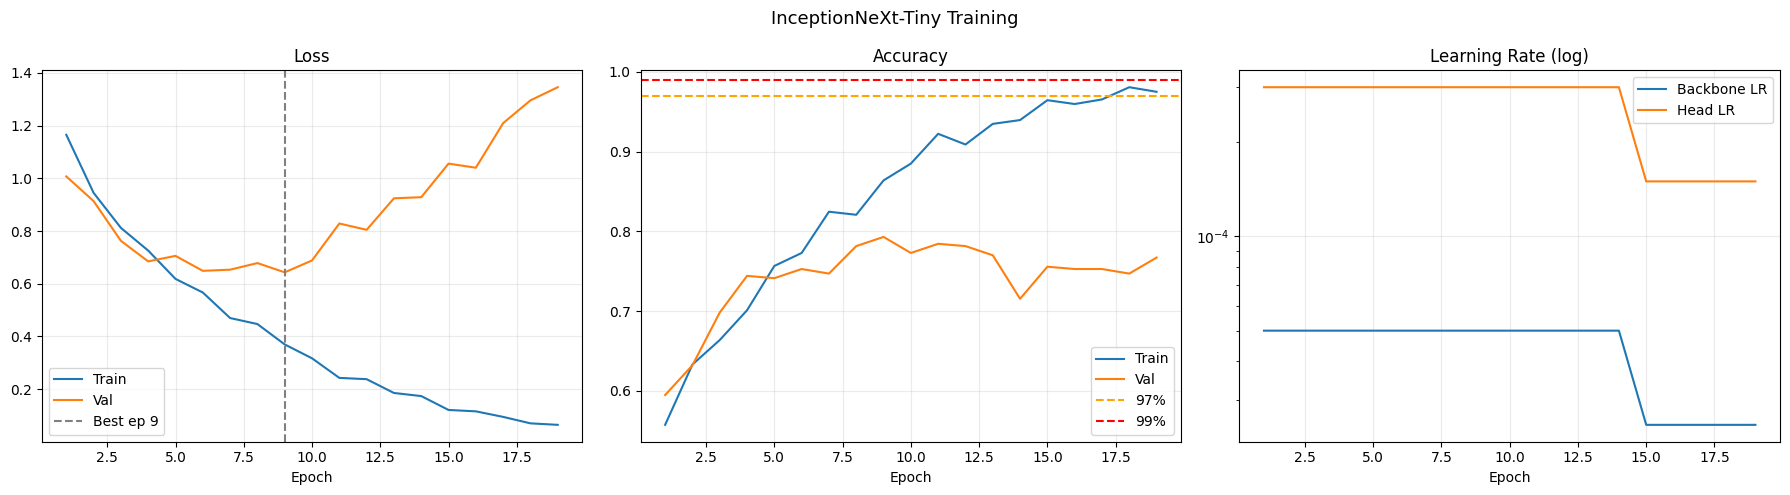

  InceptionNeXt-Tiny
  DATA_MODE     : messidor_only
  Test Accuracy : 73.85%
  Kappa (QWK)   : 0.7102
  AUC macro OVR : 0.8801
  Selected epoch: 9


In [13]:
# ==============================================
# CELL 13 - Curves + Final Summary
# ==============================================
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_DISPLAY_NAME} Training', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='gray', ls='--', label=f'Best ep {best_epoch}')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Val')
axes[1].axhline(0.97, color='orange', ls='--', label='97%')
axes[1].axhline(0.99, color='red', ls='--', label='99%')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.25)

axes[2].plot(epochs, history['bb_lr'], label='Backbone LR')
axes[2].plot(epochs, history['head_lr'], label='Head LR')
axes[2].set_title('Learning Rate (log)')
axes[2].set_xlabel('Epoch'); axes[2].set_yscale('log')
axes[2].legend(); axes[2].grid(alpha=0.25)

plt.tight_layout(); plt.show()

print('=' * 60)
print(f'  {MODEL_DISPLAY_NAME}')
print('=' * 60)
print(f'  DATA_MODE     : {DATA_MODE}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Kappa (QWK)   : {test_kappa:.4f}')
print(f'  AUC macro OVR : {test_auc:.4f}')
print(f'  Selected epoch: {best_epoch}')
print('=' * 60)


In [14]:
# ==============================================
# Dataset-mode note
# ==============================================
print('Dataset-mode setup:')
print(f'  DATA_MODE       : {DATA_MODE}')
print(f'  Train size      : {len(train_df)}')
print(f'  Val size        : {len(val_df)}')
print(f'  Test size       : {len(test_df)}')
print(f'  Train sources   : {train_df["source"].value_counts().to_dict()}')
print('  Evaluation note : Test Accuracy is computed on the full clean test split for the selected DATA_MODE.')


Dataset-mode setup:
  DATA_MODE       : messidor_only
  Train size      : 1044
  Val size        : 348
  Test size       : 348
  Train sources   : {'messidor': 1044}
  Evaluation note : Test Accuracy is computed on the full clean test split for the selected DATA_MODE.
